# Kapitel 6 - Arbeitsmarkt, Automatisierung und Grundeinkommen

## Warum wir überhaupt Dateien einlesen

Stellen wir uns vor, wir schreiben ein Programm, das irgendwas mit echten Daten machen soll:

* eine Auswertung der Einkommen aus einem Arbeitsmarkt-Datensatz (das ist der Plan für dieses Kapitel)
* eine Liste mit Temperaturen pro Tag über ein Jahr
* Sportdaten: Schritte pro Tag, gespeichert von einer App

All diese Daten liegen meistens nicht direkt im Code, sondern in einer Datei, die irgendwo auf der Festplatte (oder der Cloud) liegt. *Anmerkung, für alle denen das nicht bewusst ist: Die Cloud ist nur eine Festplatte, die jemand anderem gehört. Gleich wie das Internet generell irgendwie*)

Da zu muss Python eine Datei auf unserem Computer öffnen und einlesen können, um dann etwas mit den Daten zu tun.

Genau das machen wir jetzt mit einer CSV-Datei, die Arbeitsmarktdaten enthält.

## Was ist eine CSV-Datei?

CSV heißt: Comma-Separated Values – auf Deutsch etwa „kommagetrennte Werte“.

Das ist nichts Magisches, sondern einfach eine Textdatei, in der Daten wie in einer Tabelle stehen:

jede Zeile = eine Datensatz-Zeile (z.B. ein Jahr oder eine Person)


In der Zeile stehen mehrere Werte, getrennt durch ein Komma (oder Semikolon)

Beispiel, wie so etwas aussehen kann:
```
2000.0,2100.5,1900.0
2200.0,2300.0,2100.0
2500.0,2400.5,2600.0
```
Das könnte z.B. bedeuten:

jede Zeile = ein Jahr  
jede Zahl in der Zeile = ein Einkommen von einer Person in diesem Jahr

Unsere Aufgabe:  
Wir wollen diese Werte mit Python einlesen, damit wir danach damit rechnen können.

## Der Plan für unsere Funktion

Wir schreiben eine Funktion:

```
def read_labor_market_file(filename):
    ...
```
Diese Funktion soll:  
* die Datei öffnen
* Zeile für Zeile durchgehen
* in jeder Zeile alle Einträge von Text in Zahlen umwandeln
* am Ende eine Liste von Listen zurückgeben:
```
[
    [2000.0, 2100.5, 1900.0],   # Jahr 1
    [2200.0, 2300.0, 2100.0],   # Jahr 2
    [2500.0, 2400.5, 2600.0],   # Jahr 3
]
```

Damit kann unser Programm dann z.B. Durchschnittseinkommen pro Jahr berechnen usw.

## Neue Idee für die for-Schleife: über Listen laufen
Wir kennen for-Schleifen bisher als:


In [ ]:
liste = [1,2,3,4,5]
for it in range(len(liste)):
    print(liste[it])

Da man so etwas in der Form so oft braucht ("Python, bitte mach eine Schleife die genau so lang läuft, wie die Liste lang ist und mach im Schleifendurchgang x etwas mit dem x Element aus der Liste") gibt es dafür eine Kurzschreibweise:

In [ ]:
liste = [1,2,3,4,5]
for element in liste:
    print(element)

Das Wort `element` ist hier übrigens wie ein Variablennamen frei wählbar, wir könnten den EIntrag, der grade dran ist auch anders nennen. Diese Kurzschreibweise wird auch sehr hilfreich für unsere Einlesefunktion sein. Wir können nämlich anstelle von per Hand geschriebenen Listen auch eine ganze csv-Datei verwenden, die wir mir dem csv-Paket (nicht vergessen zu installieren und imporieren) einlesen können.

Das soll die Function machen

* Öffne ein file im Lesemodus ("r")
* Geh über alle Zeilen der Datei (Jahre)
* Leg eine leere Liste an, in der wir die einzelnen Einkommen aller Personen in diesam Jahr speichern
* Gehe über alle Einträge einer Zeile
* Gibt jedes Einkommen in die Liste
* Mach aus den 10 Jahreslisten, die wir so erstellt haben eine große Liste von Listen

Die ganze Function sieht dann so aus:

In [1]:
def read_labor_market_file(filename):
    all_incomes = []

    with open(filename, mode="r") as file:
        reader = csv.reader(file)
        # Outer loop: Go through the CSV line by line (year by year)
        for row in reader:  
            # Create an empty list to store numbers for just THIS year
            year_incomes = []
            # Inner loop: Go through every individual text entry in the current row
            for entry in row:
                # Convert text to a decimal number
                income = float(entry)
                # Add the number to this year's list
                year_incomes.append(income)

            # Add this person's completed list to the main master list
            all_incomes.append(year_incomes)
    return all_incomes

Was passiert hier genau?

`csv.reader(file)`  
macht aus der Datei einen „Leser“, der uns jede Zeile als Liste von Texten gibt.
Beispiel: aus `2000.0,2100.5,1900.0` (csv-Inhalt) wird `["2000.0", "2100.5", "1900.0"]` (Python-Daten).


`for row in reader:`   
äußere Schleife: jede Runde ist row eine komplette Zeile (also ein Jahr).



`year_incomes = []`  
wir starten eine neue Liste für dieses eine Jahr.



`for entry in row:`  
innere Schleife: wir laufen durch alle Einträge in dieser Zeile.



`income = float(entry)`  
die Einträge kommen als Text (String), z.B. "2000.0".  
Mit float(...) machen wir daraus eine Zahl, mit der wir rechnen können.  

**Ergebnis:**  
all_incomes ist eine Liste, in der jede Zeile der Datei als Liste von Zahlen gespeichert ist.

## Einlesen Testen
Jetzt schreiben wir zwei Zeilen, die testen, ob das Einlesen funktioniert hat. 

In [ ]:
all_incomes = read_labor_market_file("labormarket.csv")
print(all_incomes[0][0])

Hier kommt aber die große Hürde: Wir brauchen die Datei. Und wir müssen sie irgendwo Speichern, wo Python sie auch finden kann. Das machen wir so:

* Wir laden die Datei "labormarket.csv" von moodle oder Github heruter
* Wir speichern die Datei im gleichen Ordner wie unser py File
* Dann welchseln wir in VS Code in den gleichen Ordner und bestätigen, dass wir dem Ordner vertrauen
* Alternativ können wir direkt im Terminal mit `cd` in einen anderen Ordner wechseln

## Daten auswerten
Jetzt haben wir die Daten als Liste von Listen. Somit können wir schon eine erste Auswertung machen. Der Arbeitsmarkt in unserem Beispiel ist extrem von Automatisierung betroffen und jedes Jahr fallen etwa 10% der Jobs der Automatisierung zum Opfer (im krassen Gegensatz zum echten Arbeitsmarkt * hust *). Außerdem gibt es in dem System kein Arbeitslosengeld und keine Steuern: Wer nicht arbeitet, bekommt kein Geld. Sehen wir uns an, was das mit dem Durchschnittseinkommen macht. Hier unser gesamtes Programm soweit:



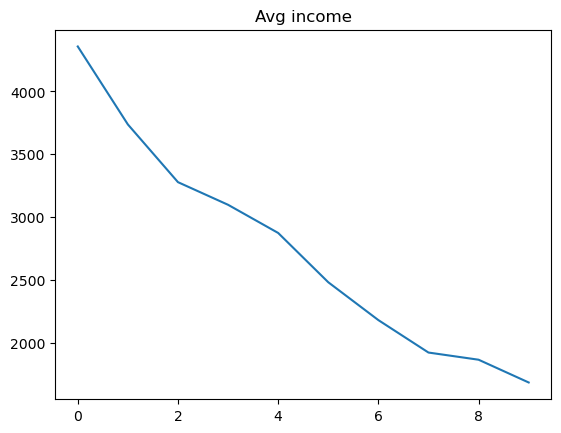

In [6]:

import csv
import matplotlib.pyplot as plt
import numpy as np


def read_labor_market_file(filename):
    all_incomes = []

    with open(filename, mode="r") as file:
        reader = csv.reader(file)
        # Outer loop: Go through the CSV line by line (year by year)
        for row in reader:  
            # Create an empty list to store numbers for just THIS year
            year_incomes = []
            # Inner loop: Go through every individual text entry in the current row
            for entry in row:
                # Convert text to a decimal number
                income = float(entry)
                # Add the number to this year's list
                year_incomes.append(income)

            # Add this person's completed list to the main master list
            all_incomes.append(year_incomes)
    return all_incomes
    
all_incomes = read_labor_market_file("labormarket.csv")
all_avgs=[]
for year in all_incomes:
    all_avgs.append(np.mean(year))

plt.plot(all_avgs)
plt.title("Avg income")
plt.show()

Wir sehen: das Durchschnittseinkommen sinkt von etwa 4500 auf unter 2000. Autsch! Aber das sind nur Durchschnitte, die Interpretation ist meist tückisch (z.B. hat ein Mensch im Durchschnitt etwa ein halbes Y-Chromosom).
Sehen wir uns die Verteilung der Einkommen an, im ersten und im letzten Jahr. Damit es übersichtlich wird, sortieren wir die Einkommen der Größe nach und machen einen Balken-Plot.

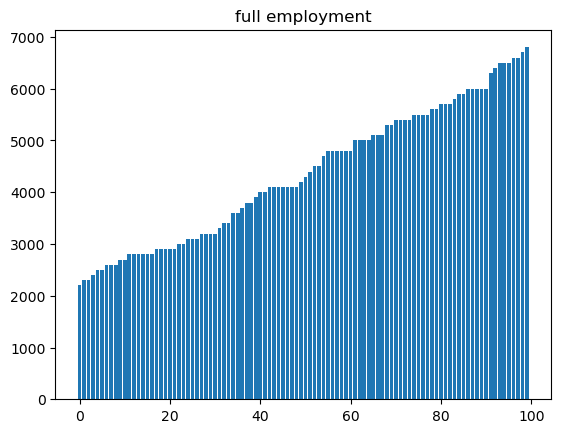

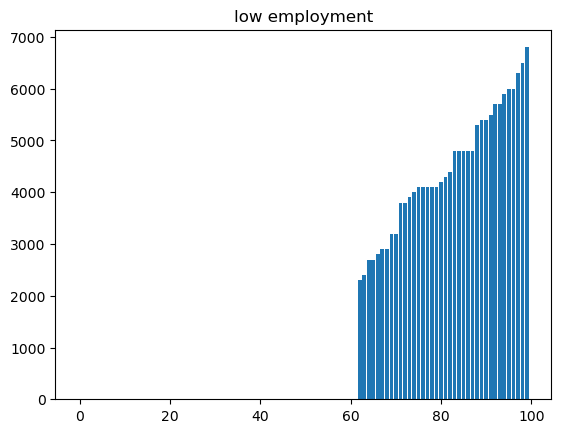

In [13]:
# Baseline: all employed:
incomes_base = all_incomes[0]
incomes_base = sorted(incomes_base)
plt.figure()
plt.bar(list(range(len(incomes_base))),incomes_base)
plt.title("full employment")

# last year:
incomes_base = all_incomes[9]
incomes_base = sorted(incomes_base)
plt.figure()
plt.bar(list(range(len(incomes_base))),incomes_base)
plt.title("low employment")
plt.show()

Ja, das ist tatsächlich heftig. 60% der Bevölkerung haben kein Einkommen mehr, die anderen 40% noch gleich viel wie früher. Das können wir natürlich nicht so stehen lassen. Versuchen wir das durch Arbeitslosengeld auszugleichen. Stark vereinfacht, könnte das so aussehen:
* Alle Personen ohne Job bekommen das Existenzminimum von 1200 Euro.
* Um diese Ausgaben zu decken, zahlen alle den gleichen Steuersatz (flat tax. nicht sehr fair, aber einfach implementierbar. Im Code und im Steuerrecht)
* Die tax rate ist also `Geld das man braucht`/`Geld das verdient wird`

Wir schreiben eine Function, die uns das Einkommen im letzen Jahr auf diese Art umverteilt:  
Wir berechnen wie viel Geld insgesamt verdient wird.  
Wir zählen die arbeitslosen Personen (also mit Einkommen 0)  
Wir berechnen wie viel Geld wir brauchen, um das Existenzminimum zu sichern.  
Wir erechnen den Steuersatz, den wir brauchen damit sich das auf 0 ausgeht.  
Wir berechnen die neuen Einkommen (1200 für die mit 0 Einkommen und `Einkommen - Steuer` für die anderen)

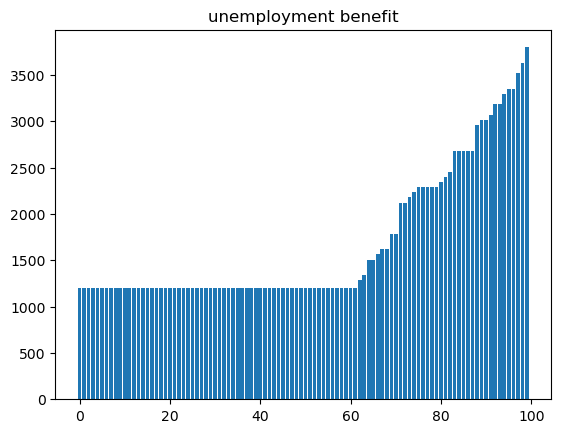

In [10]:
def unemployment_benefits(all_incomes):
    incomes=all_incomes[9]
    number_unemployed = 0
    total_tax_base = sum(incomes)

    for income in incomes:
        if income == 0:
            number_unemployed += 1
            
    total_needed = number_unemployed * 1200
    tax_rate = total_needed / total_tax_base
    
    new_incomes = []
    for income in incomes:
        if income != 0:
            income = income - tax_rate * income
        else:
            income = 1200
        new_incomes.append(income)

    return new_incomes

# Variant 1: unemployment benefits up to poverty line
incomes_ueb = unemployment_benefits(all_incomes)
incomes_ueb=sorted(incomes_ueb)
plt.figure()
plt.bar(list(range(len(incomes_ueb))),incomes_ueb)
plt.title("unemployment benefit")

Das ist zwar ein stark vereinfachtes System, aber grad deshalb auch so schön zum Experimentieren. Sehe wir uns jetzt noch an, was ein bedinungsloses Grundeinkommen (anstelle von Areitslosengeld) hier machen würde. Das läuft so:

* ALLE Personen (auch, die die arbeiten) bekommen 1200 Geldeinheiten geschenkt
* Das Geld, das man faür braucht ist einfach 1200 * Bevölkerung
* Der Steuersatz wird gleich berechnet wie voher
* Er wird höher sein, dafür bekommt man die 1200 Geldeinheiten geschenkt

Bevor wir das Implementieren können wir versuchen uns zu überlegen, in wie fern das die Verteilung ändert. Für die Leute ohne Arbeit git es nach wie vor 1200. Aber was ist mit den anderen?

So schaut unser Code dazu aus:

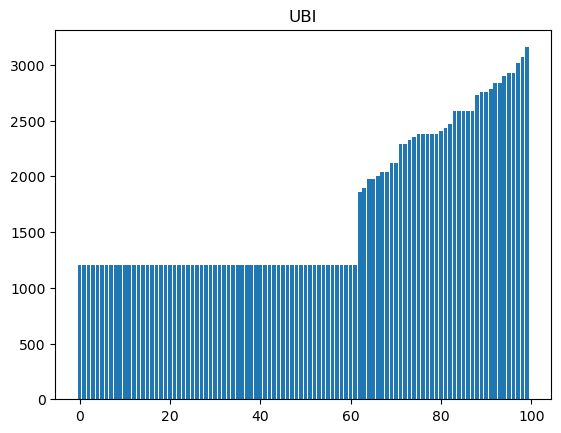

In [12]:
def ubi(all_incomes):
    incomes=all_incomes[9]

    number_persons = len(incomes)
    total_ubi_needed = number_persons * 1200

    total_tax_base = sum(incomes)

   
    tax_rate = total_ubi_needed / total_tax_base
  

    new_incomes = []

    for income in incomes:
  
        tax_paid = tax_rate * income
        new_income = income - tax_paid + 1200
        new_incomes.append(new_income)

    return new_incomes

# Variant 2: everyone gets UBI
incomes_ubi= ubi(all_incomes)

incomes_ubi = sorted(incomes_ubi)
plt.figure()
plt.bar(list(range(len(incomes_ubi))),incomes_ubi)
plt.title("UBI")
plt.show()


## Interpretation

Hier gibt es viel zu sehen und zu intepretieren: Das maximal mögliche Gehalt. Der Sprung zwischen arbeitender und nicht-arbeitender Bevölkerung (vgl. working poor). Unterschiedliche Anreize zu arbeiten oder nicht zu arbeiten oder extrem viel zu verdienen. Was as wohl für Effekte auf die Gesellschaft hätte...

## Zusammenfassung
**Schnelle for-Schleifen mit Listen**  
Bisher kannten wir `for it in range(100):`, also Schleifen über Zahlen. Genauso können wir aber direkt über Listen laufen:
```
fruits = ["apple", "banana", "cherry"]
for fruit in fruits:
    print(fruit)
```
In jeder Runde ist `fruit` ein Element der Liste. Wir brauchen keine Indexe (0, 1, 2, …) mehr, sondern arbeiten direkt mit den Werten. Das macht Code kürzer und viel besser lesbar.


 
**Daten einlesen mit dem csv-Paket**  
Mit dem csv Paket können wir Tabellen aus .csv-Dateien bequem einlesen. Dafür importieren wir zuerst das Paket und benutzen dann `csv.reader`:

```
import csv

with open("daten.csv", mode="r") as file:
    reader = csv.reader(file)
    for row in reader:
        print(row)
```
`row` ist dabei in jeder Runde eine Liste von Strings, die die Einträge einer Zeile enthält. So kommen Tabellendaten sehr einfach in unser Programm.

**Datentypen konvertieren**  
Wenn wir etwas einlesen, ist das standardmäßig eine Zeichenkette. Wollen wir, dass Python diese Zeichen als Zahl intepretiert können wir sie mit `float("42")` in eine Zahl konvertieren. Wenn man eine Ganzzahl haben will, kann man `int(...)` verwenden. Zu diesem Umwandeln sagt man auch *casten*. Auch `list(range(100))` ist eine Form von casten, hier casten wir in eine Liste. Achtung, nicht jeder Input lässt sich in jeden Datentyp casten: `float("Wingardium Leviosa")` wird zum Beispiel nur eine Fehlermeldung herbeizaubern.

**Listen von Listen**  
Manchmal brauchen wir Daten, die in Zeilen und Spalten organisiert sind – z.B. eine Tabelle. In Python speichern wir so etwas oft als Liste von Listen:

```
table = [
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9],
]
```

Zugriff funktioniert dann mit zwei Indices: `table[0][1]` ist das Element in der ersten Zeile, zweite Spalte (hier: 2).



**sorted-Befehl**  
Listen können wir mit `sorted()` sortieren. 
```
numbers = [5, 2, 9, 1]

print(sorted(numbers))
```

liefert `[1, 2, 5, 9]`